In [1]:
SEED = 24520789

# HaGRID 5-Class Object Detection (PyTorch From Scratch)

This notebook does the following:
1. Downloads HaGRID from Kaggle.
2. Builds and trains custom object detection models from scratch in PyTorch.
3. Compares model quality and speed (accuracy, precision, recall, IoU, and latency in ms).

Target classes in this notebook:
- `one` (gesture 1)
- `peace` (gesture 2)
- `three` (gesture 3)
- `four` (gesture 4)
- `fist`

In [2]:
from pathlib import Path
import os
import sys

# Essential imports needed before validation checks
import torch

def get_environment() -> str:
    """
    Detect the current execution environment: 'kaggle', 'colab', or 'local'.
    Returns a string representing the environment.
    """
    # Kaggle environment check
    if os.getenv("KAGGLE_DATA_FOLDER") or os.path.exists("/kaggle/input"):
        return "kaggle"
    
    # Colab environment check
    try:
        import google.colab  # type: ignore
        return "colab"
    except ImportError:
        pass
    
    if os.getenv("COLAB_GPU") or os.getenv("COLAB_TPU_ADDR"):
        return "colab"
    
    if os.path.exists("/content") and os.getcwd().startswith("/content"):
        return "colab"
    
    # Default to local
    return "local"

ENVIRONMENT = get_environment()
print(f"Detected environment: {ENVIRONMENT}")

# Set up paths based on environment
if ENVIRONMENT == "kaggle":
    # Kaggle environment
    DATASET_ROOT = Path("/kaggle/input/datasets/innominate817/hagrid-sample-30k-384p/hagrid-sample-30k-384p")
    MODEL_DIR = Path("/kaggle/working/models")
    OUTPUT_DIR = Path("/kaggle/working")
    
elif ENVIRONMENT == "colab":
    # Colab environment
    DATASET_ROOT = Path("/content/hagrid_dataset/hagrid-sample-30k-384p")
    MODEL_DIR = Path("/content/models")
    OUTPUT_DIR = Path("/content")
    
else:
    # Local environment
    REPO_ROOT = Path(".").resolve()
    DATASET_ROOT = REPO_ROOT / "data" / "hagrid-sample-30k-384p-5class"
    MODEL_DIR = REPO_ROOT / "models"
    OUTPUT_DIR = REPO_ROOT

# Create necessary directories (safe for all environments)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Set up device for GPU/CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Dataset root: {DATASET_ROOT}")
print(f"Model directory: {MODEL_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Device: {device}")

Detected environment: kaggle
Dataset root: /kaggle/input/datasets/innominate817/hagrid-sample-30k-384p/hagrid-sample-30k-384p
Model directory: /kaggle/working/models
Output directory: /kaggle/working
Device: cuda


In [3]:
# Environment validation and diagnostic checks
print("\n" + "="*70)
print("ENVIRONMENT VALIDATION & DIAGNOSTIC CHECKS")
print("="*70)

# Check 1: Environment detection
print(f"\n1. Environment: {ENVIRONMENT}")
if ENVIRONMENT == "kaggle":
    print("   ✓ Running on Kaggle")
elif ENVIRONMENT == "colab":
    print("   ✓ Running on Google Colab")
else:
    print("   ✓ Running locally")

# Check 2: Path validation
print(f"\n2. Path Configuration:")
print(f"   Dataset root: {DATASET_ROOT}")
print(f"   Dataset exists: {DATASET_ROOT.exists()}")
print(f"   Model directory: {MODEL_DIR}")
print(f"   Model dir exists: {MODEL_DIR.exists()}")
print(f"   Output directory: {OUTPUT_DIR}")
print(f"   Output dir exists: {OUTPUT_DIR.exists()}")

# Check 3: GPU/Device availability
print(f"\n3. Hardware Status:")
print(f"   Device: {device}")
print(f"   CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"   GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("   NOTE: Running on CPU (slower, but code will work)")

# Check 4: Dataset structure
print(f"\n4. Dataset Structure Validation:")
if DATASET_ROOT.exists():
    ann_dir = DATASET_ROOT / "ann_train_val"
    img_root = DATASET_ROOT / "hagrid_30k"
    print(f"   Annotations dir: {ann_dir.exists()}")
    print(f"   Images root: {img_root.exists()}")
    
    if ann_dir.exists():
        json_count = len(list(ann_dir.glob("*.json")))
        print(f"   JSON annotation files: {json_count}")
    
    if img_root.exists():
        subdirs = [d.name for d in img_root.iterdir() if d.is_dir()]
        print(f"   Image subdirectories: {subdirs}")
else:
    print("   ⚠ Dataset root does not exist yet (will be needed for training)")

# Check 5: Package availability
print(f"\n5. Required Packages:")
packages_ok = True
try:
    import torch as _
    print("   ✓ PyTorch")
except:
    print("   ✗ PyTorch MISSING")
    packages_ok = False

try:
    import torchvision as _
    print("   ✓ torchvision")
except:
    print("   ✗ torchvision MISSING")
    packages_ok = False

try:
    from PIL import Image as _
    print("   ✓ PIL")
except:
    print("   ✗ PIL MISSING")
    packages_ok = False

try:
    import pandas as _
    print("   ✓ pandas")
except:
    print("   ✗ pandas MISSING")
    packages_ok = False

try:
    import cv2 as _
    print("   ✓ opencv-python")
except:
    print("   ✗ opencv-python MISSING")
    packages_ok = False

print("\n" + "="*70)
if packages_ok:
    print("✓ ALL CHECKS PASSED - Ready for training!")
else:
    print("⚠ Some packages are missing - see above")
print("="*70 + "\n")


ENVIRONMENT VALIDATION & DIAGNOSTIC CHECKS

1. Environment: kaggle
   ✓ Running on Kaggle

2. Path Configuration:
   Dataset root: /kaggle/input/datasets/innominate817/hagrid-sample-30k-384p/hagrid-sample-30k-384p
   Dataset exists: True
   Model directory: /kaggle/working/models
   Model dir exists: True
   Output directory: /kaggle/working
   Output dir exists: True

3. Hardware Status:
   Device: cuda
   CUDA available: True
   GPU Name: Tesla T4
   GPU Memory: 15.64 GB

4. Dataset Structure Validation:
   Annotations dir: True
   Images root: True
   JSON annotation files: 18
   Image subdirectories: ['train_val_call', 'train_val_three', 'train_val_two_up_inverted', 'train_val_four', 'train_val_two_up', 'train_val_peace', 'train_val_three2', 'train_val_like', 'train_val_rock', 'train_val_stop', 'train_val_ok', 'train_val_fist', 'train_val_dislike', 'train_val_mute', 'train_val_one', 'train_val_peace_inverted', 'train_val_palm', 'train_val_stop_inverted']

5. Required Packages:
   

In [4]:
import os
import json
import time
import random
import shutil
import subprocess
import hashlib
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# SEED is defined in cell 1; set random seeds for reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Also set CUDA seeds for reproducibility on GPU
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# device is already defined in cell 2 (environment setup)
# Verify device is available
print("Imports complete:")
print(f"  Device: {device}")
print(f"  CUDA available: {torch.cuda.is_available()}")

# Note: REPO_ROOT and DATA_ROOT are now set in cell 2 via ENVIRONMENT detection
# This avoids conflicts with the environment-aware paths defined there.
# REGISTRY_PATH is used only for logging/diagnostics, not critical for core functionality.

REGISTRY_PATH = Path(".").resolve() / "dataset_registry.json"

def load_registry(path: Path):
    if path.exists():
        try:
            return json.loads(path.read_text(encoding="utf-8"))
        except Exception:
            pass
    return {"datasets": {}}

def save_registry(path: Path, registry: dict):
    path.write_text(json.dumps(registry, indent=2), encoding="utf-8")

def sha1_of_file(path: Path):
    if not path.exists():
        return None
    h = hashlib.sha1()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

def ensure_kaggle_installed():
    try:
        import kaggle  # noqa: F401
        print("kaggle package already available in notebook kernel")
    except Exception:
        print("Installing kaggle package in notebook kernel...")
        subprocess.check_call(["python", "-m", "pip", "install", "-q", "kaggle"])
        import kaggle  # noqa: F401
        print("kaggle package installed")

Imports complete:
  Device: cuda
  CUDA available: True


## 1) One-Time Kaggle Setup + Filtered 5-Class Dataset

This section does all of this:
- Uses the Kaggle token file from `C:/Users/<you>/.kaggle/access_token.txt`.
- Detects if the filtered HaGRID Sample 30k 384p 5-class dataset is already present in this repo.
- Builds a repo-local filtered copy that keeps only the five train classes: `one`, `peace`, `three`, `four`, `fist`.
- Stores dataset metadata in `dataset_registry.json` at repo root.
- Verifies the reduced dataset afterward by counting only the kept image folders and annotation JSONs.

Dataset reference: `innominate817/hagrid-sample-30k-384p`.

Important:
- The notebook now uses the filtered 5-class copy stored at `data/hagrid-sample-30k-384p-5class`.
- The later parsing/training cells work with that filtered dataset root.

In [5]:
# Verify dataset root and prepare dataset loading
print(f"Environment: {ENVIRONMENT}")
print(f"Using dataset root: {DATASET_ROOT}")
print(f"Dataset exists: {DATASET_ROOT.exists()}")

if DATASET_ROOT.exists():
    json_files = list(DATASET_ROOT.rglob("*.json"))
    jpg_files = list(DATASET_ROOT.rglob("*.jpg"))
    print(f"JSON files: {len(json_files)}")
    print(f"JPG files: {len(jpg_files)}")
    
    # For Kaggle, list directory structure to understand format
    if ENVIRONMENT == "kaggle" and DATASET_ROOT.exists():
        print("\nDataset structure (Kaggle HaGrid):")
        for item in list(DATASET_ROOT.iterdir())[:10]:
            print(f"  {item.name}")

Environment: kaggle
Using dataset root: /kaggle/input/datasets/innominate817/hagrid-sample-30k-384p/hagrid-sample-30k-384p
Dataset exists: True
JSON files: 18
JPG files: 31833

Dataset structure (Kaggle HaGrid):
  ann_train_val
  hagrid_30k


In [6]:
KEEP_CLASSES = ["one", "peace", "three", "four", "fist"]
TARGET_CLASSES = KEEP_CLASSES
CLASS_TO_ID = {c: i for i, c in enumerate(TARGET_CLASSES)}
ID_TO_CLASS = {i: c for c, i in CLASS_TO_ID.items()}

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print(f"Target classes: {TARGET_CLASSES}")
print(f"Class to ID mapping: {CLASS_TO_ID}")

def find_json_files(root: Path):
    return [p for p in root.rglob("*.json") if p.is_file()]

def build_filename_index(root: Path):
    """Scan the repo dataset once and index image stems to absolute paths."""
    filename_index = {}
    for img_path in root.rglob("*"):
        if img_path.is_file() and img_path.suffix.lower() in IMG_EXTS:
            filename_index.setdefault(img_path.name, img_path)
            filename_index.setdefault(img_path.stem, img_path)
    return filename_index

def resolve_image_path(filename_index: dict, image_key: str):
    key = Path(image_key).stem
    return filename_index.get(key) or filename_index.get(Path(image_key).name)

def xywh_to_xyxy(box, w, h, normalized=True):
    x, y, bw, bh = box
    if normalized:
        x *= w
        y *= h
        bw *= w
        bh *= h
    x1 = max(0.0, x)
    y1 = max(0.0, y)
    x2 = min(float(w - 1), x + bw)
    y2 = min(float(h - 1), y + bh)
    return [x1, y1, x2, y2]

def parse_hagrid_annotations(dataset_root: Path, target_classes, environment: str):
    """
    Parse HaGRID annotations based on environment.
    
    Local format:
    - ann_train_val/{class}.json
    - hagrid_30k/train_val_{class}/<image_id>.jpg
    
    Kaggle format (full dataset):
    - ann_train_val/{class}.json  (same structure as local)
    - hagrid_30k/train_val_{class}/<image_id>.jpg (same structure as local)
    
    Returns list of records with fields: image_path, bbox_xyxy, class_id
    """
    ann_dir = dataset_root / "ann_train_val"
    img_root = dataset_root / "hagrid_30k"
    
    print(f"Looking for annotations in: {ann_dir}")
    print(f"Looking for images in: {img_root}")
    
    # Find JSON files for target classes
    json_files = []
    for class_name in target_classes:
        json_path = ann_dir / f"{class_name}.json"
        if json_path.exists():
            json_files.append(json_path)
        else:
            print(f"Warning: {json_path} not found")
    
    print(f"Found {len(json_files)} annotation files for target classes")
    
    if not json_files:
        print("ERROR: No annotation files found! Check dataset structure.")
        return []
    
    print("Building filename index once (this may take a minute for Kaggle)...")
    filename_index = build_filename_index(img_root)
    print(f"Indexed {len(filename_index)} image-name entries")

    records = []
    skipped_missing_image = 0
    skipped_bad_json = 0
    skipped_non_target_class = 0

    for jf in tqdm(json_files, desc="Parsing annotations"):
        if not jf.exists():
            continue
        try:
            data = json.loads(jf.read_text(encoding="utf-8"))
        except Exception as e:
            print(f"Error reading {jf}: {e}")
            skipped_bad_json += 1
            continue

        if not isinstance(data, dict):
            skipped_bad_json += 1
            continue

        for image_key, item in data.items():
            if not isinstance(item, dict):
                continue

            labels = item.get("labels") or []
            bboxes = item.get("bboxes") or []
            if not labels or not bboxes:
                continue

            img_path = resolve_image_path(filename_index, image_key)
            if img_path is None:
                skipped_missing_image += 1
                continue

            try:
                with Image.open(img_path) as img_pil:
                    img_pil = img_pil.convert("RGB")
                    w, h = img_pil.size
            except Exception:
                continue

            for label, box in zip(labels, bboxes):
                if label not in target_classes:
                    skipped_non_target_class += 1
                    continue
                if not isinstance(box, (list, tuple)) or len(box) < 4:
                    continue
                normalized = max(box[:4]) <= 1.5
                x1, y1, x2, y2 = xywh_to_xyxy(box[:4], w, h, normalized=normalized)
                records.append({
                    "image_path": str(img_path),
                    "bbox_xyxy": [x1, y1, x2, y2],
                    "class_id": CLASS_TO_ID[label],
                })

    print(f"Parsing complete:")
    print(f"  Valid records: {len(records)}")
    print(f"  Skipped missing-image: {skipped_missing_image}")
    print(f"  Skipped unreadable JSON: {skipped_bad_json}")
    print(f"  Skipped non-target classes: {skipped_non_target_class}")
    
    return records

# Parse dataset with environment-aware handler
print("\n" + "="*60)
print(f"Parsing HaGRID dataset ({ENVIRONMENT} environment)")
print("="*60)

records = parse_hagrid_annotations(DATASET_ROOT, TARGET_CLASSES, ENVIRONMENT)
print(f"\nParsed records (raw): {len(records)}")

# Filter to single-hand images only (images that appear exactly once)
img_counts = Counter(r['image_path'] for r in records)
single_records = [r for r in records if img_counts[r['image_path']] == 1]
print(f"Records before filter: {len(records)}, after filter (single-hand only): {len(single_records)}")
records = single_records

if len(records) == 0:
    print("ERROR: No samples parsed after single-hand filtering. Check dataset structure and annotation schema.")
else:
    print(f"✓ Successfully parsed {len(records)} single-hand gesture samples")

Target classes: ['one', 'peace', 'three', 'four', 'fist']
Class to ID mapping: {'one': 0, 'peace': 1, 'three': 2, 'four': 3, 'fist': 4}

Parsing HaGRID dataset (kaggle environment)
Looking for annotations in: /kaggle/input/datasets/innominate817/hagrid-sample-30k-384p/hagrid-sample-30k-384p/ann_train_val
Looking for images in: /kaggle/input/datasets/innominate817/hagrid-sample-30k-384p/hagrid-sample-30k-384p/hagrid_30k
Found 5 annotation files for target classes
Building filename index once (this may take a minute for Kaggle)...
Indexed 63666 image-name entries


Parsing annotations:   0%|          | 0/5 [00:00<?, ?it/s]

Parsing complete:
  Valid records: 8837
  Skipped missing-image: 132568
  Skipped unreadable JSON: 0
  Skipped non-target classes: 2067

Parsed records (raw): 8837
Records before filter: 8837, after filter (single-hand only): 8837
✓ Successfully parsed 8837 single-hand gesture samples


Train: 6185, Val: 1325, Test: 1327


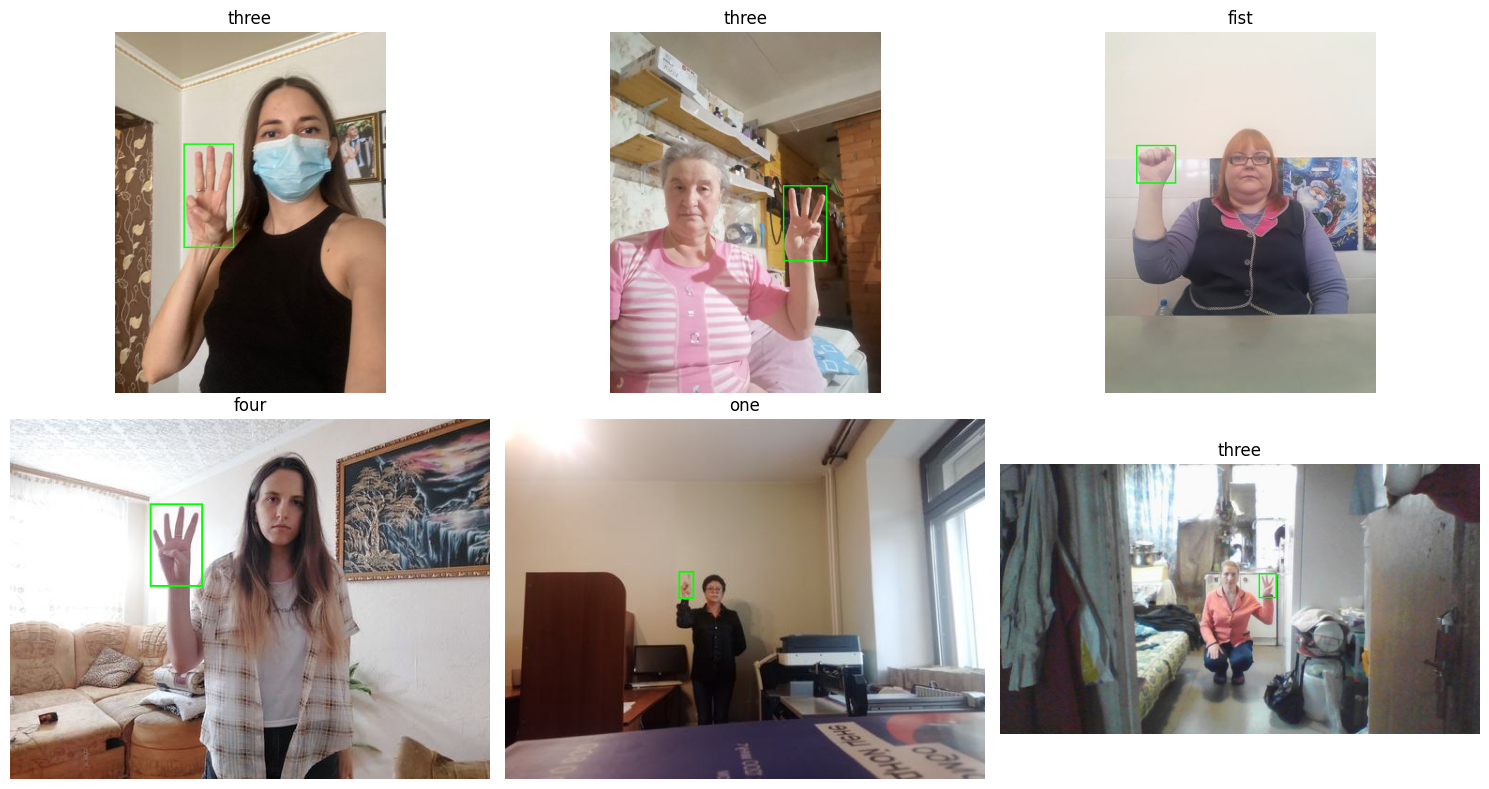

In [7]:
# Use the exact filtered 5-class dataset already prepared in the repo.
random.shuffle(records)

n = len(records)
n_train = int(0.7 * n)
n_val = int(0.15 * n)

train_records = records[:n_train]
val_records = records[n_train:n_train + n_val]
test_records = records[n_train + n_val:]

print(f"Train: {len(train_records)}, Val: {len(val_records)}, Test: {len(test_records)}")


def draw_box(image, box, color, width=2):
    draw = ImageDraw.Draw(image)
    for offset in range(width):
        draw.rectangle(
            [box[0] - offset, box[1] - offset, box[2] + offset, box[3] + offset],
            outline=color,
        )


def show_samples(samples, n_show=6):
    if len(samples) == 0:
        print("No samples to show")
        return
    idxs = np.random.choice(len(samples), size=min(n_show, len(samples)), replace=False)
    plt.figure(figsize=(15, 8))
    for i, idx in enumerate(idxs, 1):
        s = samples[idx]
        with Image.open(s["image_path"]) as img_pil:
            img = img_pil.convert("RGB")
        x1, y1, x2, y2 = map(int, s["bbox_xyxy"])
        draw_box(img, (x1, y1, x2, y2), color=(0, 255, 0), width=2)
        plt.subplot(2, 3, i)
        plt.imshow(img)
        plt.title(ID_TO_CLASS[s["class_id"]])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(train_records, n_show=6)

In [8]:
IMG_SIZE = 320
BATCH_SIZE = 32
GRID_SIZE = 10  # 320 / 32 downsampling ratio

# Optimize num_workers based on environment and OS
# Windows: always use 0 (multiprocessing issues)
# Linux/Mac on Kaggle/Colab: use 2 for cloud throughput
if ENVIRONMENT in ["kaggle", "colab"]:
    NUM_WORKERS = 2
else:
    import platform
    if platform.system() == "Windows":
        NUM_WORKERS = 0
    else:
        NUM_WORKERS = 2

print(f"DataLoader configuration:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Image size: {IMG_SIZE}×{IMG_SIZE}")
print(f"  Grid size: {GRID_SIZE}")
print(f"  Num workers: {NUM_WORKERS}")
print(f"  Environment: {ENVIRONMENT}")

def normalize_box_xyxy(box, w, h):
    x1, y1, x2, y2 = box
    return [x1 / w, y1 / h, x2 / w, y2 / h]

class GestureGridDataset(Dataset):
    def __init__(self, records, img_size=320, grid_size=10, augment=False):
        self.records = records
        self.img_size = img_size
        self.grid_size = grid_size
        self.augment = augment

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        with Image.open(r["image_path"]) as img_pil:
            img = img_pil.convert("RGB")
            w, h = img.size
            x1, y1, x2, y2 = r["bbox_xyxy"]

            if self.augment:
                if random.random() > 0.5:
                    img = img.transpose(Image.FLIP_LEFT_RIGHT)
                    new_x1 = w - x2
                    new_x2 = w - x1
                    x1, x2 = new_x1, new_x2
                if random.random() > 0.5:
                    from PIL import ImageEnhance
                    enhancer = ImageEnhance.Brightness(img)
                    img = enhancer.enhance(random.uniform(0.8, 1.2))

            x1_n, y1_n, x2_n, y2_n = normalize_box_xyxy([x1, y1, x2, y2], w, h)
            img = img.resize((self.img_size, self.img_size), Image.Resampling.BILINEAR)
            img = np.asarray(img, dtype=np.float32) / 255.0
            img = np.transpose(img, (2, 0, 1))

            target = torch.zeros((self.grid_size, self.grid_size, 6), dtype=torch.float32)
            cx, cy = (x1_n + x2_n) / 2.0, (y1_n + y2_n) / 2.0
            box_w, box_h = max(0.0, x2_n - x1_n), max(0.0, y2_n - y1_n)

            cell_x = min(max(int(cx * self.grid_size), 0), self.grid_size - 1)
            cell_y = min(max(int(cy * self.grid_size), 0), self.grid_size - 1)

            rel_cx = (cx * self.grid_size) - cell_x
            rel_cy = (cy * self.grid_size) - cell_y

            target[cell_y, cell_x, 0] = 1.0
            target[cell_y, cell_x, 1:5] = torch.tensor([rel_cx, rel_cy, box_w, box_h], dtype=torch.float32)
            target[cell_y, cell_x, 5] = float(r["class_id"])

        return {"image": torch.tensor(img, dtype=torch.float32), "target": target}

train_ds = GestureGridDataset(train_records, img_size=IMG_SIZE, grid_size=GRID_SIZE, augment=True)
val_ds = GestureGridDataset(val_records, img_size=IMG_SIZE, grid_size=GRID_SIZE, augment=False)
test_ds = GestureGridDataset(test_records, img_size=IMG_SIZE, grid_size=GRID_SIZE, augment=False)

# Create DataLoaders with environment-optimized settings
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"\n✓ DataLoaders created:")
print(f"  Train batches: {len(train_loader)} ({len(train_ds)} samples)")
print(f"  Val batches: {len(val_loader)} ({len(val_ds)} samples)")
print(f"  Test batches: {len(test_loader)} ({len(test_ds)} samples)")

DataLoader configuration:
  Batch size: 32
  Image size: 320×320
  Grid size: 10
  Num workers: 2
  Environment: kaggle

✓ DataLoaders created:
  Train batches: 194 (6185 samples)
  Val batches: 42 (1325 samples)
  Test batches: 42 (1327 samples)


In [9]:
import torchvision.models as models

class TransferMobileNetSSD(nn.Module):
    """
    Pretrained MobileNetV3-Large backbone + SSD-style grid head.
    Replaces the previous YOLO-style head with an SSD-like detection head
    (same output layout: obj, box, cls) so the training pipeline and loss stay unchanged.
    """
    def __init__(self, num_classes=5, grid_size=10, freeze_backbone_until=13):
        super().__init__()
        self.num_classes = num_classes
        self.grid_size = grid_size

        # Load pretrained MobileNetV3-Large
        if hasattr(models, "MobileNet_V3_Large_Weights"):
            weights = models.MobileNet_V3_Large_Weights.DEFAULT
            mobilenet = models.mobilenet_v3_large(weights=weights)
        else:
            mobilenet = models.mobilenet_v3_large(pretrained=True)

        self.backbone = mobilenet.features

        # Freeze early generic filters to preserve low-level features
        for layer in self.backbone[:freeze_backbone_until]:
            for param in layer.parameters():
                param.requires_grad = False

        # Adapter conv: MobileNetV3-Large outputs 960 channels
        # Use HardSwish to match MobileNetV3 internals and preserve activation statistics.
        self.adapt_conv = nn.Sequential(
            nn.Conv2d(960, 256, kernel_size=1, bias=False),
            nn.BatchNorm2d(256),
            nn.Hardswish(inplace=True)
        )

        # SSD-like detection head (keeps same channel layout expected by yolo_loss)
        self.detection_head = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.Hardswish(inplace=True),
            nn.Conv2d(128, 1 + 4 + num_classes, kernel_size=1)
        )

    def forward(self, x):
        feat = self.backbone(x)
        feat = self.adapt_conv(feat)
        feat = F.adaptive_avg_pool2d(feat, output_size=(self.grid_size, self.grid_size))

        out = self.detection_head(feat)
        out = out.permute(0, 2, 3, 1)

        obj_logits = out[..., 0]
        box_preds = torch.sigmoid(out[..., 1:5])
        cls_logits = out[..., 5:]
        return obj_logits, box_preds, cls_logits

# Keep aliases used elsewhere in the notebook
MobileNetV2SSDDetector = TransferMobileNetSSD
MiniGridDetector = TransferMobileNetSSD

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

clean_model = TransferMobileNetSSD(num_classes=len(TARGET_CLASSES), grid_size=GRID_SIZE).to(device)
print(f"Pretrained MobileNetV3-Large SSD Detector loaded. Total trainable parameters: {count_params(clean_model):,}")
print("✓ Pretrained MobileNetV3 backbone")
print("✓ 10x10 grid-compatible SSD-style head")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 129MB/s] 


Pretrained MobileNetV3-Large SSD Detector loaded. Total trainable parameters: 2,722,194
✓ Pretrained MobileNetV3 backbone
✓ 10x10 grid-compatible SSD-style head


In [10]:
def box_iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a[..., 0], a[..., 1], a[..., 2], a[..., 3]
    bx1, by1, bx2, by2 = b[..., 0], b[..., 1], b[..., 2], b[..., 3]
    inter_x1 = torch.maximum(ax1, bx1)
    inter_y1 = torch.maximum(ay1, by1)
    inter_x2 = torch.minimum(ax2, bx2)
    inter_y2 = torch.minimum(ay2, by2)
    inter_w = torch.clamp(inter_x2 - inter_x1, min=0)
    inter_h = torch.clamp(inter_y2 - inter_y1, min=0)
    inter = inter_w * inter_h
    area_a = torch.clamp(ax2 - ax1, min=0) * torch.clamp(ay2 - ay1, min=0)
    area_b = torch.clamp(bx2 - bx1, min=0) * torch.clamp(by2 - by1, min=0)
    union = area_a + area_b - inter + 1e-7
    return inter / union

def yolo_loss(obj_logits, box_preds, cls_logits, target_grid, w_obj=1.0, w_box=5.0, w_cls=1.0):
    obj_target = target_grid[..., 0]
    box_target = target_grid[..., 1:5]
    cls_target = target_grid[..., 5].long()

    # Weight the positive object cell much more strongly than background cells.
    # This counteracts the severe class imbalance from one positive cell vs. many empty cells.
    grid_h = target_grid.shape[1]
    grid_w = target_grid.shape[2]
    pos_weight_val = float(grid_h * grid_w - 1)
    pos_weight = torch.tensor([pos_weight_val], device=obj_logits.device)

    loss_obj = F.binary_cross_entropy_with_logits(
        obj_logits,
        obj_target,
        pos_weight=pos_weight,
    )

    obj_mask = obj_target == 1.0
    if obj_mask.sum() > 0:
        loss_box = F.smooth_l1_loss(box_preds[obj_mask], box_target[obj_mask])
        loss_cls = F.cross_entropy(cls_logits[obj_mask], cls_target[obj_mask])
    else:
        loss_box = torch.tensor(0.0, device=box_preds.device)
        loss_cls = torch.tensor(0.0, device=cls_logits.device)
    total_loss = (w_obj * loss_obj) + (w_box * loss_box) + (w_cls * loss_cls)
    return total_loss, loss_obj.item(), loss_box.item(), loss_cls.item()

@torch.no_grad()
def decode_batch_predictions(obj_logits, box_preds, cls_logits, target_grid, grid_size=10):
    batch_size = obj_logits.size(0)
    pred_labels, gt_labels, pred_boxes_xyxy, gt_boxes_xyxy = [], [], [], []
    obj_probs = torch.sigmoid(obj_logits)
    for i in range(batch_size):
        pred_flat_idx = torch.argmax(obj_probs[i])
        py, px = int((pred_flat_idx // grid_size).item()), int((pred_flat_idx % grid_size).item())
        gt_obj = target_grid[i, ..., 0]
        if torch.any(gt_obj == 1.0):
            gt_flat_idx = torch.argmax(gt_obj)
            gy, gx = int((gt_flat_idx // grid_size).item()), int((gt_flat_idx % grid_size).item())
        else:
            gy, gx = py, px
        p_rel, g_rel = box_preds[i, py, px], target_grid[i, gy, gx, 1:5]
        p_cx, p_cy = (px + p_rel[0]) / grid_size, (py + p_rel[1]) / grid_size
        g_cx, g_cy = (gx + g_rel[0]) / grid_size, (gy + g_rel[1]) / grid_size
        p_box = torch.stack([p_cx - (p_rel[2] / 2), p_cy - (p_rel[3] / 2), p_cx + (p_rel[2] / 2), p_cy + (p_rel[3] / 2)]).clamp(0, 1)
        g_box = torch.stack([g_cx - (g_rel[2] / 2), g_cy - (g_rel[3] / 2), g_cx + (g_rel[2] / 2), g_cy + (g_rel[3] / 2)]).clamp(0, 1)
        pred_boxes_xyxy.append(p_box)
        gt_boxes_xyxy.append(g_box)
        pred_labels.append(int(torch.argmax(cls_logits[i, py, px]).item()))
        gt_labels.append(int(target_grid[i, gy, gx, 5].item()))
    return pred_labels, gt_labels, torch.stack(pred_boxes_xyxy), torch.stack(gt_boxes_xyxy)

@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    gt_labels, pred_labels, ious, all_lat_ms = [], [], [], []
    for batch in tqdm(loader, leave=False):
        x, target_grid = batch["image"].to(device), batch["target"].to(device)
        if device.type == "cuda": torch.cuda.synchronize()
        t0 = time.perf_counter()
        obj_logits, box_preds, cls_logits = model(x)
        if device.type == "cuda": torch.cuda.synchronize()
        t1 = time.perf_counter()
        all_lat_ms.extend([(t1 - t0) * 1000.0 / x.size(0)] * x.size(0))
        p_l, g_l, p_b, g_b = decode_batch_predictions(obj_logits, box_preds, cls_logits, target_grid, GRID_SIZE)
        gt_labels.extend(g_l); pred_labels.extend(p_l); ious.extend(box_iou_xyxy(p_b, g_b).cpu().numpy().tolist())
    acc = accuracy_score(gt_labels, pred_labels)
    prec, rec, f1, _ = precision_recall_fscore_support(gt_labels, pred_labels, average="macro", zero_division=0)
    return {"accuracy": acc, "precision_macro": prec, "recall_macro": rec, "f1_macro": f1, "mean_iou": float(np.mean(ious)), "latency_mean_ms": float(np.mean(all_lat_ms))}

def fit_model(model, train_loader, val_loader, epochs=2, lr=1e-3, save_path=None):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    best_acc = 0.0
    for ep in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for batch in tqdm(train_loader, leave=False):
            x, target_grid = batch["image"].to(device), batch["target"].to(device)
            optimizer.zero_grad()
            obj_logits, box_preds, cls_logits = model(x)
            loss, _, _, _ = yolo_loss(obj_logits, box_preds, cls_logits, target_grid)
            loss.backward(); optimizer.step()
            train_loss += loss.item() * x.size(0)
        train_loss /= len(train_loader.dataset)
        val_metrics = evaluate_model(model, val_loader)
        history.append({"epoch": ep, "train_loss": train_loss, **val_metrics})

        # --- Best Model Logic ---
        if val_metrics['accuracy'] > best_acc:
            best_acc = val_metrics['accuracy']
            if save_path:
                torch.save({"model_state_dict": model.state_dict(), "accuracy": best_acc}, save_path)
                print(f"Epoch {ep:02d} | New Best Val Acc: {best_acc:.4f} (Saved)")
        else:
            print(f"Epoch {ep:02d} | loss={train_loss:.4f} | val_acc={val_metrics['accuracy']:.4f}")
    return pd.DataFrame(history)

def fit_model_with_scheduler(model, train_loader, val_loader, epochs=20, lr=1e-4, save_path=None, **model_metadata):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

    history = []
    best_acc = 0.0
    best_epoch_model_state = None # To store the state_dict of the best model

    for ep in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        t0 = time.perf_counter()

        for batch in tqdm(train_loader, leave=False):
            x, target_grid = batch["image"].to(device), batch["target"].to(device)
            optimizer.zero_grad()
            obj_logits, box_preds, cls_logits = model(x)
            loss, l_obj, l_box, l_cls = yolo_loss(obj_logits, box_preds, cls_logits, target_grid)
            loss.backward(); optimizer.step()
            train_loss += loss.item() * x.size(0)

        t1 = time.perf_counter()
        epoch_time = t1 - t0
        avg_train_loss = train_loss / len(train_loader.dataset)

        val_metrics = evaluate_model(model, val_loader)
        scheduler.step(val_metrics['accuracy'])

        status = {"epoch": ep, "train_loss": avg_train_loss, "latency_ms": (epoch_time/len(train_loader))*1000, **val_metrics}
        history.append(status)

        print(f"Epoch {ep:02d} | Loss: {avg_train_loss:.4f} | Val Acc: {val_metrics['accuracy']:.4f} | Latency: {val_metrics['latency_mean_ms']:.2f}ms")

        if val_metrics['accuracy'] > best_acc:
            best_acc = val_metrics['accuracy']
            best_epoch_model_state = model.state_dict() # Save the state_dict
            print(f"--- New Best Val Acc: {best_acc:.4f} (Model Saved) ---")
            if save_path:
                # Prepare checkpoint to save
                checkpoint_to_save = {
                    "model_state_dict": best_epoch_model_state,
                    "best_accuracy": best_acc, # Save the best accuracy achieved
                    **model_metadata # Include other metadata like class_to_id, img_size etc.
                }
                torch.save(checkpoint_to_save, save_path)
                print(f"Model checkpoint saved to {save_path} for best accuracy: {best_acc:.4f}")

    return pd.DataFrame(history)

In [11]:
@torch.no_grad()
def decode_single_prediction(obj_logits, box_preds, cls_logits, w, h, grid_size=10):
    """
    Decodes the single most confident prediction from the model's grid output.
    Returns: [x1, y1, x2, y2], class_id, confidence_score
    """
    obj_probs = torch.sigmoid(obj_logits[0])  # [10, 10]

    # Find the grid cell with the highest objectness score
    flat_idx = torch.argmax(obj_probs)
    py, px = int(flat_idx // grid_size), int(flat_idx % grid_size)
    score = obj_probs[py, px].item()

    # Get relative box coords from that cell
    rel = box_preds[0, py, px]  # [rel_cx, rel_cy, bw, bh]

    # Convert to absolute coordinates
    cx = (px + rel[0]) / grid_size
    cy = (py + rel[1]) / grid_size
    bw, bh = rel[2], rel[3]

    x1, y1 = (cx - bw/2) * w, (cy - bh/2) * h
    x2, y2 = (cx + bw/2) * w, (cy + bh/2) * h

    # Get class ID
    class_id = torch.argmax(cls_logits[0, py, px]).item()

    return [x1.item(), y1.item(), x2.item(), y2.item()], int(class_id), float(score)

In [12]:
from torchvision.ops import nms

def decode_and_nms(obj_logits, box_preds, cls_logits, grid_size=10, score_threshold=0.5, iou_threshold=0.4):
    """
    Decodes all grid cells and applies Non-Maximum Suppression.
    This is essential for live detection where a hand might overlap multiple grid cells.
    """
    batch_size = obj_logits.size(0)
    final_preds = []

    obj_probs = torch.sigmoid(obj_logits) # [B, 10, 10]

    for b in range(batch_size):
        # Flatten the grid to [100]
        probs = obj_probs[b].view(-1)
        mask = probs > score_threshold

        if not mask.any():
            final_preds.append(None)
            continue

        # Get valid boxes and their scores
        filtered_probs = probs[mask]
        # Get grid indices for the mask
        indices = torch.nonzero(mask).squeeze(1)
        py = indices // grid_size
        px = indices % grid_size

        # Get the predicted relative box coords
        rel_boxes = box_preds[b, py, px] # [N, 4]

        # Convert rel to absolute xyxy
        p_cx = (px.float() + rel_boxes[:, 0]) / grid_size
        p_cy = (py.float() + rel_boxes[:, 1]) / grid_size
        p_w, p_h = rel_boxes[:, 2], rel_boxes[:, 3]

        boxes = torch.stack([
            p_cx - p_w/2, p_cy - p_h/2,
            p_cx + p_w/2, p_cy + p_h/2
        ], dim=1).clamp(0, 1)

        # Apply NMS
        keep_idx = nms(boxes, filtered_probs, iou_threshold)

        # Get class labels for the kept boxes
        class_ids = torch.argmax(cls_logits[b, py, px], dim=1)

        final_preds.append({
            "boxes": boxes[keep_idx],
            "scores": filtered_probs[keep_idx],
            "labels": class_ids[keep_idx]
        })

    return final_preds

print("NMS post-processing logic integrated for better live detection stability.")

NMS post-processing logic integrated for better live detection stability.


In [13]:
import matplotlib.patches as patches

@torch.no_grad()
def visualize_resnet_nms(model, dataset, n_show=4, score_thr=0.5, iou_thr=0.4):
    model.eval()
    indices = np.random.choice(len(dataset), size=n_show, replace=False)

    fig, axs = plt.subplots(1, n_show, figsize=(20, 5))
    if n_show == 1: axs = [axs]

    for i, idx in enumerate(indices):
        batch = dataset[idx]
        img_tensor = batch["image"].unsqueeze(0).to(device)

        # Inference
        obj_logits, box_preds, cls_logits = model(img_tensor)

        # Apply your new NMS logic
        preds = decode_and_nms(obj_logits, box_preds, cls_logits,
                               grid_size=GRID_SIZE,
                               score_threshold=score_thr,
                               iou_threshold=iou_thr)[0]

        # Convert tensor to image for display
        img = img_tensor[0].cpu().permute(1, 2, 0).numpy()
        axs[i].imshow(img)
        axs[i].axis("off")

        if preds is not None:
            for box, score, label in zip(preds["boxes"], preds["scores"], preds["labels"]):
                x1, y1, x2, y2 = box.cpu().numpy() * IMG_SIZE
                rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='r', facecolor='none')
                axs[i].add_patch(rect)
                axs[i].set_title(f"{ID_TO_CLASS[int(label)]} ({score:.2f})")
        else:
            axs[i].set_title("No detection")

print("ResNet visualization helper with NMS is ready.")

ResNet visualization helper with NMS is ready.


In [14]:
# Debug cell: single-batch forward/backward timing and basic checks
print("--- Debug: single-batch smoke test ---")
print("Device:", device)
print("CUDA available:", torch.cuda.is_available())

try:
    batch = next(iter(train_loader))
except Exception as e:
    print("Failed to fetch a batch from train_loader:", e)
    raise

x = batch["image"].to(device)
target = batch["target"].to(device)
print("Batch shapes -> image:", x.shape, " target:", target.shape)

if device.type == "cuda": torch.cuda.synchronize()
t0 = time.perf_counter()
obj_logits, box_preds, cls_logits = clean_model(x)
if device.type == "cuda": torch.cuda.synchronize()
t1 = time.perf_counter()
print(f"Forward time: {t1 - t0:.4f}s (batch size {x.size(0)})")

loss, l_obj, l_box, l_cls = yolo_loss(obj_logits, box_preds, cls_logits, target)
print("Loss summary -> total:", float(loss), "obj:", l_obj, "box:", l_box, "cls:", l_cls)

# quick backward+step sanity (small LR, single step)
opt = torch.optim.SGD(clean_model.parameters(), lr=1e-3)
opt.zero_grad()
loss.backward()
opt.step()
print("Ran one backward+step")

# Print some activation statistics
print("obj_logits stats -> mean, std:", float(obj_logits.mean()), float(obj_logits.std()))
print("cls_logits stats -> mean, std:", float(cls_logits.mean()), float(cls_logits.std()))
print("box_preds stats -> mean, std:", float(box_preds.mean()), float(box_preds.std()))

# Check how many positive object targets are present in this batch
obj_targets = target[..., 0]
print("Positive object targets in batch:", int(obj_targets.sum().item()), "/", obj_targets.numel())

# Print class distribution in this batch
classes = target[..., 5].long()
unique, counts = torch.unique(classes, return_counts=True)
print("Class ids present and counts:")
for u, c in zip(unique.cpu().numpy(), counts.cpu().numpy()):
    print(int(u), int(c))

print("--- End debug ---")

--- Debug: single-batch smoke test ---
Device: cuda
CUDA available: True
Batch shapes -> image: torch.Size([32, 3, 320, 320])  target: torch.Size([32, 10, 10, 6])
Forward time: 0.9130s (batch size 32)


/tmp/ipykernel_23/987266192.py:24: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print("Loss summary -> total:", float(loss), "obj:", l_obj, "box:", l_box, "cls:", l_cls)


Loss summary -> total: 3.4123151302337646 obj: 1.3534643650054932 box: 0.06097966805100441 cls: 1.7539523839950562
Ran one backward+step
obj_logits stats -> mean, std: -0.041871603578329086 0.32932278513908386
cls_logits stats -> mean, std: -0.034093599766492844 0.338117778301239
box_preds stats -> mean, std: 0.4940750002861023 0.07849309593439102
Positive object targets in batch: 32 / 3200
Class ids present and counts:
0 3173
1 7
2 5
3 7
4 8
--- End debug ---


In [15]:
# Two-phase transfer learning: Freeze (head-only) -> Thaw (full fine-tune)
print(f"Training on {ENVIRONMENT} environment")
print(f"Device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")

MODEL_PATH = MODEL_DIR / "mobilenet_ssd_hagrid_detector.pt"

# Guided pipeline hyperparameters
HEAD_EPOCHS = 6
HEAD_LR = 1e-2
FINETUNE_EPOCHS = 35
FINETUNE_LR = 5e-4

print(f"Pipeline Configured: {IMG_SIZE}x{IMG_SIZE} Res | {HEAD_EPOCHS + FINETUNE_EPOCHS} Total Epochs")

clean_model = TransferMobileNetSSD(num_classes=len(TARGET_CLASSES), grid_size=GRID_SIZE).to(device)
print("\nTwo-phase transfer configuration:")
print(f"  Resolution: {IMG_SIZE}×{IMG_SIZE}")
print(f"  Grid size: {GRID_SIZE}")
print(f"  Phase 1 (Head): epochs={HEAD_EPOCHS}, lr={HEAD_LR}")
print(f"  Phase 2 (Full): epochs={FINETUNE_EPOCHS}, lr={FINETUNE_LR}")
print(f"  Total params: {sum(p.numel() for p in clean_model.parameters()):,}")
print(f"  Trainable params initially: {sum(p.numel() for p in clean_model.parameters() if p.requires_grad):,}")


def set_backbone_trainable(model, trainable: bool):
    """Freezes or unfreezes MobileNet backbone weights."""
    for p in model.backbone.parameters():
        p.requires_grad = trainable


def run_training_phase(model, train_loader, val_loader, phase_name, epochs, lr, start_epoch_idx=0):
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(trainable_params, lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

    phase_history = []
    phase_best_acc = -1.0
    phase_best_state = None

    print(f"\n--- Starting {phase_name} | Epochs: {epochs} | LR: {lr} ---")

    for ep in range(1, epochs + 1):
        model.train()

        # Critical BN fix: keep frozen backbone BN stats untouched in Phase 1.
        if phase_name == "phase1_head":
            model.backbone.eval()

        train_loss = 0.0
        t0 = time.perf_counter()

        for batch in tqdm(train_loader, leave=False):
            x, target_grid = batch["image"].to(device), batch["target"].to(device)

            optimizer.zero_grad()
            obj_logits, box_preds, cls_logits = model(x)
            loss, _, _, _ = yolo_loss(obj_logits, box_preds, cls_logits, target_grid)

            loss.backward()
            optimizer.step()
            train_loss += loss.item() * x.size(0)

        t1 = time.perf_counter()
        avg_train_loss = train_loss / len(train_loader.dataset)

        val_metrics = evaluate_model(model, val_loader)
        scheduler.step(val_metrics["accuracy"])

        global_epoch = start_epoch_idx + ep
        current_lr = optimizer.param_groups[0]["lr"]

        row = {
            "epoch": global_epoch,
            "phase": phase_name,
            "train_loss": avg_train_loss,
            "lr": current_lr,
            "latency_ms": ((t1 - t0) / len(train_loader)) * 1000,
            **val_metrics,
        }
        phase_history.append(row)

        if val_metrics["accuracy"] > phase_best_acc:
            phase_best_acc = val_metrics["accuracy"]
            from copy import deepcopy
            phase_best_state = deepcopy(model.state_dict())

        print(
            f"Epoch {global_epoch:02d} [{phase_name}] | "
            f"Loss: {avg_train_loss:.4f} | Val Acc: {val_metrics['accuracy']:.4f} | LR: {current_lr:.2e}"
        )

    return phase_history, phase_best_acc, phase_best_state


def fit_model_freeze_thaw(model, train_loader, val_loader, save_path=None, **model_metadata):
    from copy import deepcopy

    full_history = []
    best_acc = -1.0
    best_state = None

    # ==========================================
    # PHASE 1: Freeze Backbone, Train Head Fast
    # ==========================================
    set_backbone_trainable(model, trainable=False)

    # Ensure SSD head remains trainable.
    for p in model.adapt_conv.parameters():
        p.requires_grad = True
    for p in model.detection_head.parameters():
        p.requires_grad = True

    phase1_history, phase1_best_acc, phase1_best_state = run_training_phase(
        model,
        train_loader,
        val_loader,
        phase_name="phase1_head",
        epochs=HEAD_EPOCHS,
        lr=HEAD_LR,
        start_epoch_idx=0,
    )
    full_history.extend(phase1_history)

    if phase1_best_acc > best_acc and phase1_best_state is not None:
        best_acc = phase1_best_acc
        best_state = deepcopy(phase1_best_state)

    # ==========================================
    # PHASE 2: Unfreeze Backbone, Fine-Tune
    # ==========================================
    set_backbone_trainable(model, trainable=True)

    phase2_history, phase2_best_acc, phase2_best_state = run_training_phase(
        model,
        train_loader,
        val_loader,
        phase_name="phase2_full",
        epochs=FINETUNE_EPOCHS,
        lr=FINETUNE_LR,
        start_epoch_idx=HEAD_EPOCHS,
    )
    full_history.extend(phase2_history)

    if phase2_best_acc > best_acc and phase2_best_state is not None:
        best_acc = phase2_best_acc
        best_state = deepcopy(phase2_best_state)

    # ==========================================
    # WRAP UP & SAVE
    # ==========================================
    if best_state is not None:
        model.load_state_dict(best_state)

    if save_path is not None and best_state is not None:
        torch.save({
            "model_state_dict": best_state,
            "best_accuracy": best_acc,
            "img_size": IMG_SIZE,
            "grid_size": GRID_SIZE,
            "class_to_id": CLASS_TO_ID,
            "model_name": "TransferMobileNetV2_SSD",
            **model_metadata,
        }, save_path)
        print(f"\n[SUCCESS] Best model saved to {save_path} with Val Acc: {best_acc:.4f}")

    return pd.DataFrame(full_history)


history_df = fit_model_freeze_thaw(
    clean_model,
    train_loader,
    val_loader,
    save_path=MODEL_PATH,
)

print("\n" + "=" * 60)
print("Two-phase training complete")
print("=" * 60)
print(f"Best model saved to: {MODEL_PATH}")
print(f"Environment: {ENVIRONMENT}")

Training on kaggle environment
Device: cuda
CUDA available: True
Pipeline Configured: 320x320 Res | 41 Total Epochs

Two-phase transfer configuration:
  Resolution: 320×320
  Grid size: 10
  Phase 1 (Head): epochs=6, lr=0.01
  Phase 2 (Full): epochs=35, lr=0.0005
  Total params: 3,514,682
  Trainable params initially: 2,722,194

--- Starting phase1_head | Epochs: 6 | LR: 0.01 ---


  0%|          | 0/194 [00:00<?, ?it/s]

  0%|          | 0/42 [00:00<?, ?it/s]

Epoch 01 [phase1_head] | Loss: 1.4223 | Val Acc: 0.6362 | LR: 1.00e-02


  0%|          | 0/194 [00:00<?, ?it/s]

...

  0%|          | 0/42 [00:00<?, ?it/s]

Epoch 40 [phase2_full] | Loss: 0.0075 | Val Acc: 0.9185 | LR: 3.13e-05


  0%|          | 0/194 [00:00<?, ?it/s]

  0%|          | 0/42 [00:00<?, ?it/s]

Epoch 41 [phase2_full] | Loss: 0.0060 | Val Acc: 0.9192 | LR: 3.13e-05

[SUCCESS] Best model saved to /kaggle/working/models/mobilenet_ssd_hagrid_detector.pt with Val Acc: 0.9192

Two-phase training complete
Best model saved to: /kaggle/working/models/mobilenet_ssd_hagrid_detector.pt
Environment: kaggle


In [16]:
# Multi-environment model download/save handler
print(f"Environment: {ENVIRONMENT}")
print(f"Model directory: {MODEL_DIR}")

model_to_download = MODEL_DIR / "mobilenet_ssd_hagrid_detector.pt"

if not model_to_download.exists():
    print(f"Model file not found at {model_to_download}. Please ensure training was completed.")
else:
    print(f"✓ Model found at {model_to_download}")

    if ENVIRONMENT == "colab":
        # Colab: download to local machine
        try:
            from google.colab import files
            print(f"Downloading '{model_to_download.name}' to your local machine...")
            files.download(str(model_to_download))
            print(f"✓ '{model_to_download.name}' downloaded successfully")
        except ImportError:
            print("ERROR: google.colab not available. Not on Colab?")

    elif ENVIRONMENT == "kaggle":
        # Kaggle: model already saved to /kaggle/working
        print(f"✓ Model saved to Kaggle output: {model_to_download}")
        print("  Download from 'Output' tab in Kaggle notebook")

    else:
        # Local: model already in local repository
        print(f"✓ Model saved locally: {model_to_download}")

Environment: kaggle
Model directory: /kaggle/working/models
✓ Model found at /kaggle/working/models/mobilenet_ssd_hagrid_detector.pt
✓ Model saved to Kaggle output: /kaggle/working/models/mobilenet_ssd_hagrid_detector.pt
  Download from 'Output' tab in Kaggle notebook


Evaluating test set for confusion matrix...


  0%|          | 0/42 [00:00<?, ?it/s]

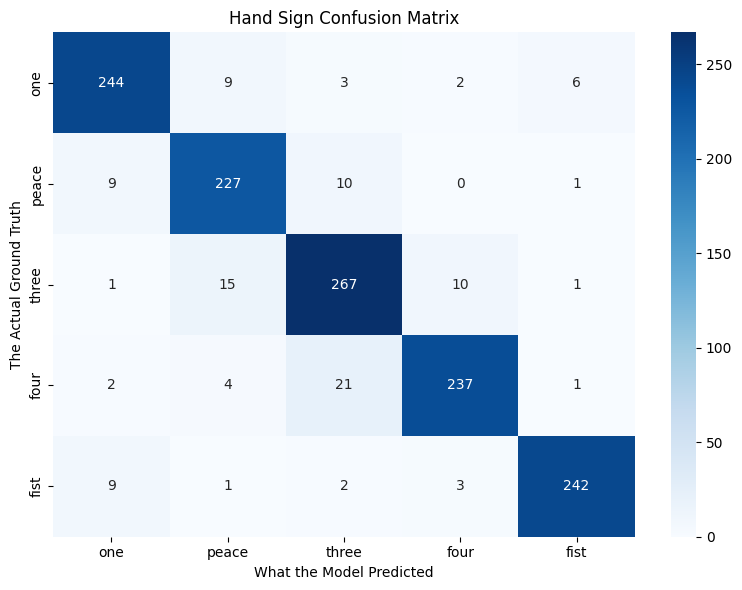

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

@torch.no_grad()
def plot_confusion_matrix(model, loader, id_to_class):
    """Generates a confusion-matrix heatmap of predictions vs ground truth."""
    model.eval()
    all_preds = []
    all_gts = []

    print("Evaluating test set for confusion matrix...")
    for batch in tqdm(loader, leave=False):
        x, target_grid = batch["image"].to(device), batch["target"].to(device)
        obj_logits, box_preds, cls_logits = model(x)

        p_l, g_l, _, _ = decode_batch_predictions(obj_logits, box_preds, cls_logits, target_grid, GRID_SIZE)
        all_preds.extend(p_l)
        all_gts.extend(g_l)

    class_names = [id_to_class[i] for i in range(len(id_to_class))]
    cm = confusion_matrix(all_gts, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.xlabel('What the Model Predicted')
    plt.ylabel('The Actual Ground Truth')
    plt.title('Hand Sign Confusion Matrix')
    plt.tight_layout()
    plt.show()


if 'clean_model' in globals():
    plot_confusion_matrix(clean_model, test_loader, ID_TO_CLASS)
else:
    print("Model not trained yet.")

In [18]:
@torch.no_grad()
def visualize_predictions(model, dataset, n_show=8, score_thr=0.1, iou_thr=0.4):
    if len(dataset) == 0:
        print("Dataset empty")
        return

    model.eval()
    idxs = np.random.choice(len(dataset), size=min(n_show, len(dataset)), replace=False)
    plt.figure(figsize=(20, 12))

    for i, idx in enumerate(idxs, 1):
        sample = dataset.records[idx]
        with Image.open(sample["image_path"]) as img_pil:
            img = img_pil.convert("RGB")
            w, h = img.size

            # Prep input
            resized = img.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.BILINEAR)
            x = np.asarray(resized, dtype=np.float32) / 255.0
            xt = torch.tensor(np.transpose(x, (2, 0, 1)), dtype=torch.float32).unsqueeze(0).to(device)

            # Inference
            obj_logits, box_preds, cls_logits = model(xt)
            preds_list = decode_and_nms(obj_logits, box_preds, cls_logits, grid_size=GRID_SIZE, score_threshold=score_thr, iou_threshold=iou_thr)
            preds = preds_list[0]

            # Draw Ground Truth (Green)
            gx1, gy1, gx2, gy2 = map(int, sample["bbox_xyxy"])
            draw_box(img, (gx1, gy1, gx2, gy2), color=(0, 255, 0), width=3)

            pred_text = "No Detection"
            if preds is not None and len(preds["boxes"]) > 0:
                # NMS returns normalized [0, 1] coords
                box = preds["boxes"][0].cpu().numpy()
                score = preds["scores"][0].item()
                label = preds["labels"][0].item()

                # RESCALE TO PIXELS
                px1, py1 = int(box[0] * w), int(box[1] * h)
                px2, py2 = int(box[2] * w), int(box[3] * h)

                print(f"Img {i} | Box Norm: {box} | Box Pixel: {[px1, py1, px2, py2]}")

                draw_box(img, (px1, py1, px2, py2), color=(255, 0, 0), width=5)
                pred_text = f"Pred: {ID_TO_CLASS[label]} ({score:.2f})"

            plt.subplot((n_show + 3) // 4, 4, i)
            plt.imshow(img)
            plt.title(f"GT: {ID_TO_CLASS[sample['class_id']]}\n{pred_text}")
            plt.axis("off")

    plt.tight_layout()
    plt.show()

Img 1 | Box Norm: [0.5285701 0.5505106 0.5901237 0.614062 ] | Box Pixel: [202, 375, 226, 418]
Img 2 | Box Norm: [0.1665494  0.40332636 0.31031007 0.54922795] | Box Pixel: [63, 206, 119, 281]
Img 3 | Box Norm: [0.         0.16568056 0.3146396  0.5216013 ] | Box Pixel: [0, 84, 120, 267]
Img 4 | Box Norm: [0.6512222  0.4051311  0.8030888  0.63379264] | Box Pixel: [444, 155, 548, 243]
Img 5 | Box Norm: [0.18578151 0.30058604 0.37025878 0.6132577 ] | Box Pixel: [71, 153, 142, 313]
Img 6 | Box Norm: [0.35883033 0.2994046  0.45915586 0.40397552] | Box Pixel: [137, 153, 176, 207]
Img 7 | Box Norm: [0.6727569  0.37368402 0.8013948  0.5357609 ] | Box Pixel: [258, 191, 307, 274]
Img 8 | Box Norm: [0.08803635 0.3801596  0.21461537 0.603035  ] | Box Pixel: [33, 194, 82, 308]


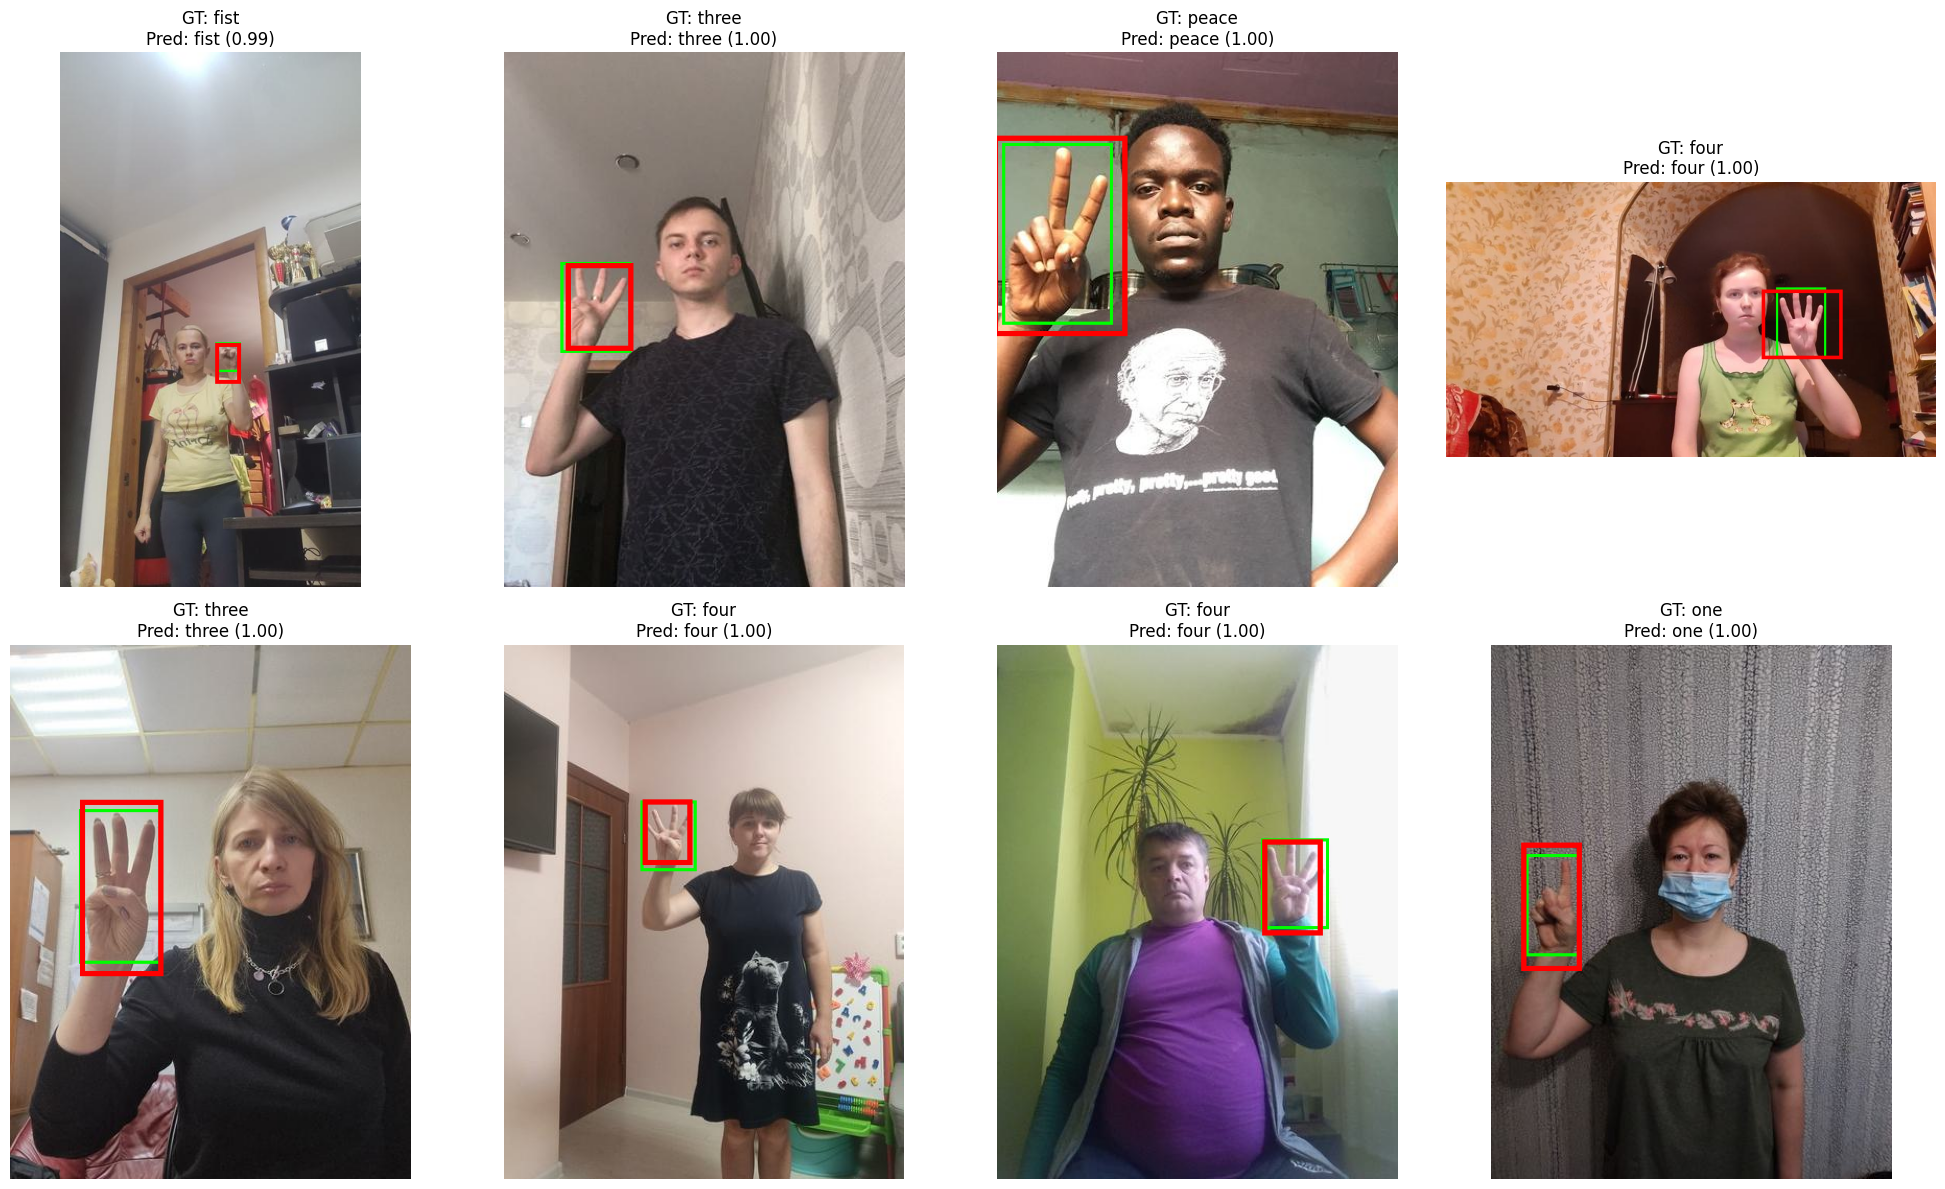

In [19]:
# Re-running visualization with red prediction boxes and score threshold 0.3
visualize_predictions(clean_model, test_ds, n_show=8, score_thr=0.3)

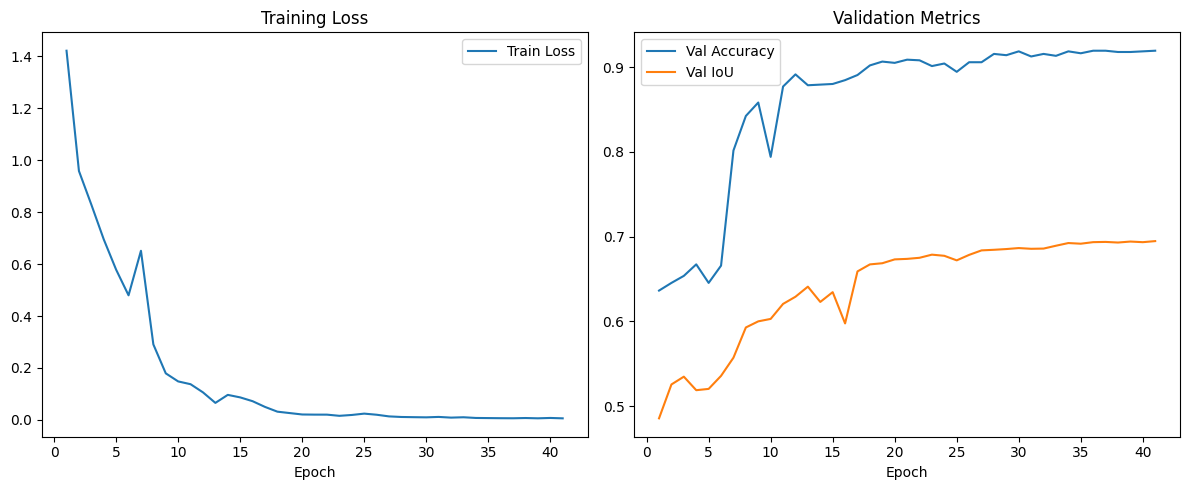

In [20]:
def plot_history(df):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(df['epoch'], df['train_loss'], label='Train Loss')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(df['epoch'], df['accuracy'], label='Val Accuracy')
    plt.plot(df['epoch'], df['mean_iou'], label='Val IoU')
    plt.title('Validation Metrics')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()
    plt.show()

if 'history_df' in globals():
    plot_history(history_df)
else:
    print("History not found. Ensure the training cell was executed.")

### Using the Trained Model for Inference

Here's how you can load your trained model and use it to make predictions on new images. You would typically do this in a separate script or when deploying your model.

Environment: kaggle
Device: cuda
GPU available: True
✓ Model 'TransferMobileNetV2_SSD' loaded from /kaggle/working/models/mobilenet_ssd_hagrid_detector.pt
  Image size: 320, Grid size: 10
  Best accuracy achieved: 0.9192

✗ No objects detected

✓ Visualization saved to: /kaggle/working/inference_visualization.png


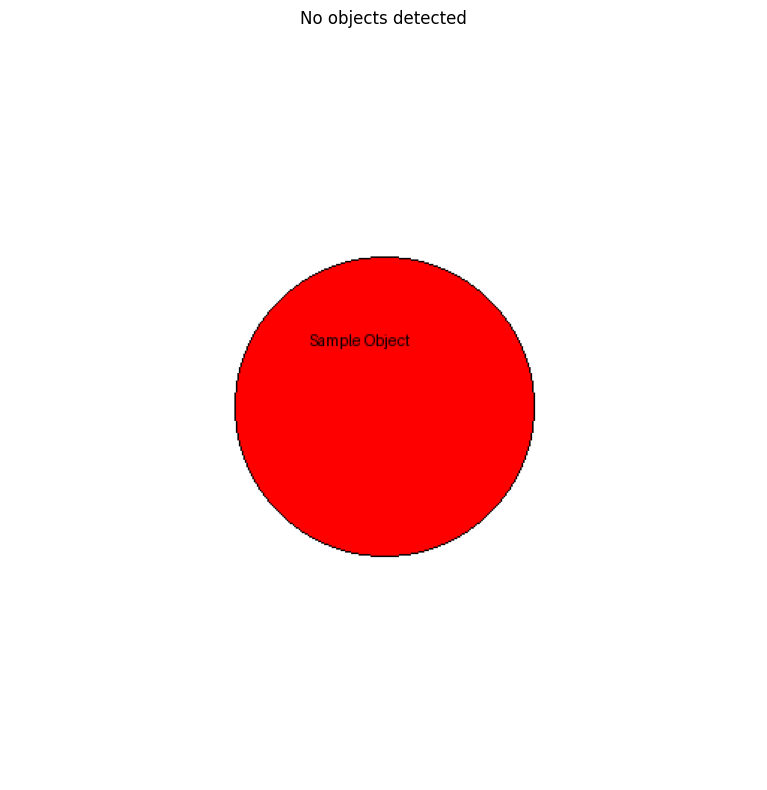

In [21]:
import torch
from PIL import Image, ImageDraw
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ============================================================================
# Multi-environment model loading and inference
# ============================================================================

print(f"Environment: {ENVIRONMENT}")
print(f"Device: {device}")

# Detect GPU availability
has_gpu = torch.cuda.is_available()
print(f"GPU available: {has_gpu}")

if ENVIRONMENT == "kaggle" and not has_gpu:
    print("WARNING: Running on Kaggle but no GPU detected. Performance may be slow.")

# Load model checkpoint from environment-specific path
model_path = MODEL_DIR / "mobilenet_ssd_hagrid_detector.pt"

if not model_path.exists():
    print(f"ERROR: Model checkpoint not found at {model_path}")
    print("Please run the training cell first.")
else:
    checkpoint = torch.load(model_path, map_location=device)

    # Initialize the model architecture
    loaded_model = MobileNetV2SSDDetector(
        num_classes=len(checkpoint['class_to_id']),
        grid_size=checkpoint['grid_size']
    ).to(device)
    loaded_model.load_state_dict(checkpoint['model_state_dict'])
    loaded_model.eval()

    print(f"✓ Model '{checkpoint.get('model_name', 'TransferMobileNetV2_SSD')}' loaded from {model_path}")
    print(f"  Image size: {checkpoint['img_size']}, Grid size: {checkpoint['grid_size']}")
    print(f"  Best accuracy achieved: {checkpoint.get('best_accuracy', 0.0):.4f}")

    # Use the parameters from the loaded checkpoint
    INFERENCE_IMG_SIZE = checkpoint['img_size']
    INFERENCE_GRID_SIZE = checkpoint['grid_size']
    INFERENCE_ID_TO_CLASS = {v: k for k, v in checkpoint['class_to_id'].items()}

    # Demo image (replace with a real image path for production inference)
    original_img_pil = Image.new('RGB', (500, 500), color='white')
    draw = ImageDraw.Draw(original_img_pil)
    draw.ellipse([150, 150, 350, 350], fill=(255, 0, 0), outline=(0, 0, 0))
    draw.text((200, 200), "Sample Object", fill=(0, 0, 0))

    w_orig, h_orig = original_img_pil.size

    # Preprocess the image
    resized_img_pil = original_img_pil.resize((INFERENCE_IMG_SIZE, INFERENCE_IMG_SIZE), Image.Resampling.BILINEAR)
    x = np.asarray(resized_img_pil, dtype=np.float32) / 255.0
    xt = torch.tensor(np.transpose(x, (2, 0, 1)), dtype=torch.float32).unsqueeze(0).to(device)

    # Perform inference
    with torch.no_grad():
        obj_logits, box_preds, cls_logits = loaded_model(xt)

    # Decode predictions using NMS
    preds_list = decode_and_nms(
        obj_logits,
        box_preds,
        cls_logits,
        grid_size=INFERENCE_GRID_SIZE,
        score_threshold=0.3,
        iou_threshold=0.4,
    )
    preds = preds_list[0]

    # Visualize results
    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(original_img_pil)
    ax.axis("off")

    if preds is not None and len(preds["boxes"]) > 0:
        print(f"\n✓ Detected {len(preds['boxes'])} object(s):")
        for box, score, label in zip(preds["boxes"], preds["scores"], preds["labels"]):
            # Rescale normalized box coordinates back to original image dimensions
            x1, y1, x2, y2 = box.cpu().numpy()
            x1_abs, y1_abs, x2_abs, y2_abs = x1 * w_orig, y1 * h_orig, x2 * w_orig, y2 * h_orig

            rect = patches.Rectangle(
                (x1_abs, y1_abs),
                x2_abs - x1_abs,
                y2_abs - y1_abs,
                linewidth=2,
                edgecolor='r',
                facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(
                x1_abs,
                y1_abs - 5,
                f"{INFERENCE_ID_TO_CLASS[label.item()]} ({score:.2f})",
                bbox=dict(facecolor='yellow', alpha=0.5),
                fontsize=10,
                color='black'
            )
            print(f"  • {INFERENCE_ID_TO_CLASS[label.item()]}: {score:.2f} confidence")
            print(f"    Box: [{x1_abs:.1f}, {y1_abs:.1f}, {x2_abs:.1f}, {y2_abs:.1f}]")
    else:
        ax.set_title("No objects detected")
        print("\n✗ No objects detected")

    plt.tight_layout()

    # Save visualization based on environment
    if ENVIRONMENT == "kaggle":
        output_path = OUTPUT_DIR / "inference_visualization.png"
        plt.savefig(output_path, dpi=100, bbox_inches='tight')
        print(f"\n✓ Visualization saved to: {output_path}")
    elif ENVIRONMENT == "colab":
        output_path = OUTPUT_DIR / "inference_visualization.png"
        plt.savefig(output_path, dpi=100, bbox_inches='tight')
        print(f"\n✓ Visualization saved to: {output_path}")

    plt.show()